In [1]:
import os
from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt

%matplotlib inline

# Set base paths
PROJECT_ROOT = r"D:\IIT\4 th Year\Machine Vision\Course Work\Car-Damage-Detection-YOLO"
DATA_DIR = os.path.join(PROJECT_ROOT, "data", "car_damage_yolo")
CONFIG_PATH = os.path.join(PROJECT_ROOT, "config", "car_damage.yaml")

print("PROJECT_ROOT:", PROJECT_ROOT)
print("DATA_DIR:", DATA_DIR)
print("CONFIG_PATH:", CONFIG_PATH)

PROJECT_ROOT: D:\IIT\4 th Year\Machine Vision\Course Work\Car-Damage-Detection-YOLO
DATA_DIR: D:\IIT\4 th Year\Machine Vision\Course Work\Car-Damage-Detection-YOLO\data\car_damage_yolo
CONFIG_PATH: D:\IIT\4 th Year\Machine Vision\Course Work\Car-Damage-Detection-YOLO\config\car_damage.yaml


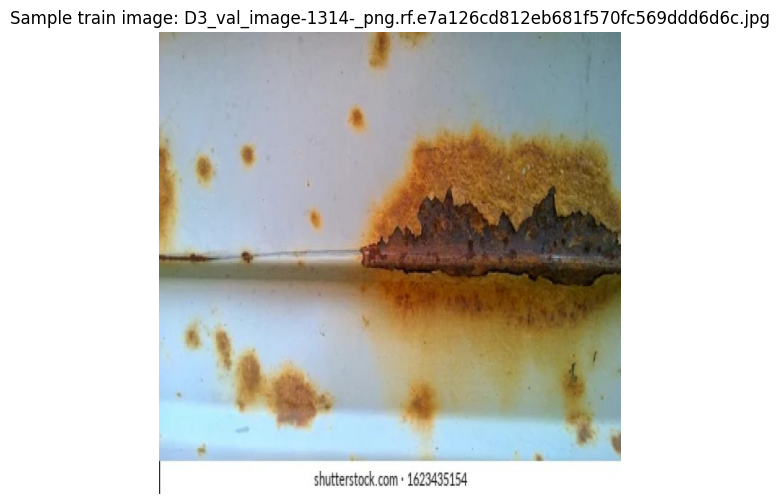

In [2]:
import random

train_images_dir = os.path.join(DATA_DIR, "images", "train")
sample_img_name = random.choice(os.listdir(train_images_dir))
sample_img_path = os.path.join(train_images_dir, sample_img_name)

img = cv2.imread(sample_img_path)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(6, 6))
plt.imshow(img_rgb)
plt.title(f"Sample train image: {sample_img_name}")
plt.axis("off")
plt.show()

In [4]:
import torch

print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("CUDA device count:", torch.cuda.device_count())
    print("Current device:", torch.cuda.current_device())
    print("Device name:", torch.cuda.get_device_name(0))

Torch version: 2.9.1+cu126
CUDA available: True
CUDA device count: 1
Current device: 0
Device name: NVIDIA GeForce RTX 2050


In [5]:
model = YOLO("yolov8s.pt")
model

YOLO(
  (model): DetectionModel(
    (model): Sequential(
      (0): Conv(
        (conv): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (1): Conv(
        (conv): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(64, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (2): C2f(
        (cv1): Conv(
          (conv): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn): BatchNorm2d(64, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
          (act): SiLU(inplace=True)
        )
        (cv2): Conv(
          (conv): Conv2d(96, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn): BatchNorm2d(64, eps=0.001, momentum=0.03, affine=True, track_running_s

In [6]:
results = model.train(
    data=CONFIG_PATH,
    epochs=50,
    imgsz=640,
    batch=8,
    name="car_damage_yolov8s",
    project=os.path.join(PROJECT_ROOT, "models", "runs"),
    patience=10,
    device=0   
)

Ultralytics 8.3.233  Python-3.11.9 torch-2.9.1+cu126 CUDA:0 (NVIDIA GeForce RTX 2050, 4096MiB)
engine\trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=D:\IIT\4 th Year\Machine Vision\Course Work\Car-Damage-Detection-YOLO\config\car_damage.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=car_damage_yolov8s, nbs=64, nms=False, opset=None, optimize=False,

In [7]:
metrics = model.val(
    data=CONFIG_PATH,
    imgsz=640,
    split="val"
)

metrics

Ultralytics 8.3.233  Python-3.11.9 torch-2.9.1+cu126 CUDA:0 (NVIDIA GeForce RTX 2050, 4096MiB)
Model summary (fused): 72 layers, 11,128,293 parameters, 0 gradients, 28.5 GFLOPs
val: Fast image access  (ping: 0.10.0 ms, read: 426.0275.7 MB/s, size: 414.3 KB)
val: Scanning D:\IIT\4 th Year\Machine Vision\Course Work\Car-Damage-Detection-YOLO\data\car_damage_yolo\labels\val.cache... 1907 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1907/1907 1.9Mit/s 0.0s
WARNING Box and segment counts should be equal, but got len(segments) = 1961, len(boxes) = 5436. To resolve this only boxes will be used and all segments will be removed. To avoid this please supply either a detect or segment dataset, not a detect-segment mixed dataset.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 120/120 2.6it/s 46.0s0.3s
                   all       1907       5436      0.787      0.653      0.714      0.554
                  dent        675        9

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3, 4, 5, 6])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x0000022AF0223F90>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047

In [9]:
import numpy as np

mean_precision = float(np.mean(metrics.box.p))  # average over classes
mean_recall    = float(np.mean(metrics.box.r))  # average over classes

summary = {
    "mAP50": float(metrics.box.map50),
    "mAP50_95": float(metrics.box.map),
    "precision": mean_precision,
    "recall": mean_recall,
}

summary

{'mAP50': 0.7137792561800108,
 'mAP50_95': 0.5543746223060257,
 'precision': 0.7868669807070637,
 'recall': 0.6533741290936349}

In [10]:
class_names = ["dent", "scratch", "crack", "glass shatter", "lamp broken", "tire flat", "rust"]

for i, name in enumerate(class_names):
    print(f"{name:15s}  P={metrics.box.p[i]:.3f}  R={metrics.box.r[i]:.3f}")

dent             P=0.744  R=0.566
scratch          P=0.649  R=0.347
crack            P=0.680  R=0.468
glass shatter    P=0.979  R=0.959
lamp broken      P=0.851  R=0.824
tire flat        P=0.843  R=0.938
rust             P=0.761  R=0.472



image 1/1 D:\IIT\4 th Year\Machine Vision\Course Work\Car-Damage-Detection-YOLO\data\car_damage_yolo\images\test\D1_test_damaged-car-scratch-16930537_jpg.rf.b8db82ae3a87c827b442ff793bf5ed3e.jpg: 640x640 4 scratchs, 22.8ms
Speed: 2.0ms preprocess, 22.8ms inference, 1.8ms postprocess per image at shape (1, 3, 640, 640)


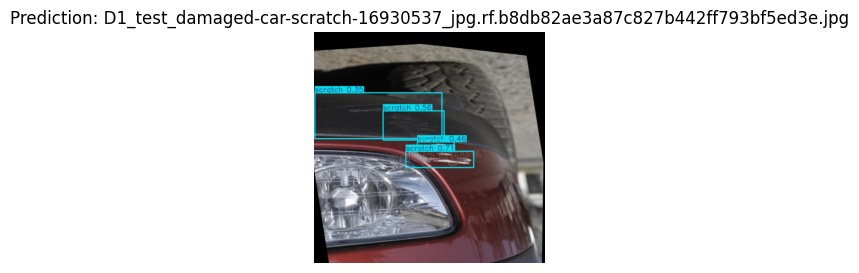


image 1/1 D:\IIT\4 th Year\Machine Vision\Course Work\Car-Damage-Detection-YOLO\data\car_damage_yolo\images\test\D1_test_minor-dent-scratches-bumper-car-involved-accident-97896523_jpg.rf.90891d12981e5dc88bb67a5e558b3bdc.jpg: 640x640 1 scratch, 23.9ms
Speed: 1.6ms preprocess, 23.9ms inference, 1.7ms postprocess per image at shape (1, 3, 640, 640)


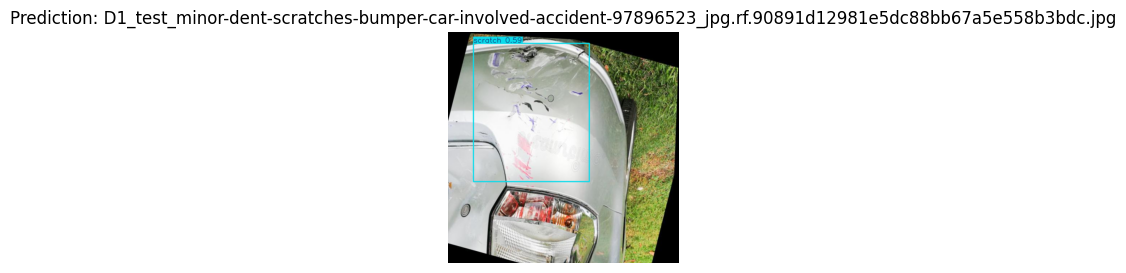


image 1/1 D:\IIT\4 th Year\Machine Vision\Course Work\Car-Damage-Detection-YOLO\data\car_damage_yolo\images\test\D1_train_1_jpg.rf.cfd349c71249272d0eeb169a50725394.jpg: 640x640 7 scratchs, 25.6ms
Speed: 1.8ms preprocess, 25.6ms inference, 1.8ms postprocess per image at shape (1, 3, 640, 640)


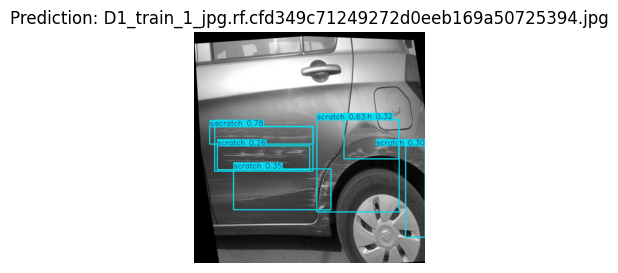


image 1/1 D:\IIT\4 th Year\Machine Vision\Course Work\Car-Damage-Detection-YOLO\data\car_damage_yolo\images\test\D1_train_742cec8b48ddb02fe35069dc9bf0ad0a_jpg.rf.a73c63f04f2e871b03a298eda2604c94.jpg: 640x640 2 scratchs, 25.8ms
Speed: 1.6ms preprocess, 25.8ms inference, 2.1ms postprocess per image at shape (1, 3, 640, 640)


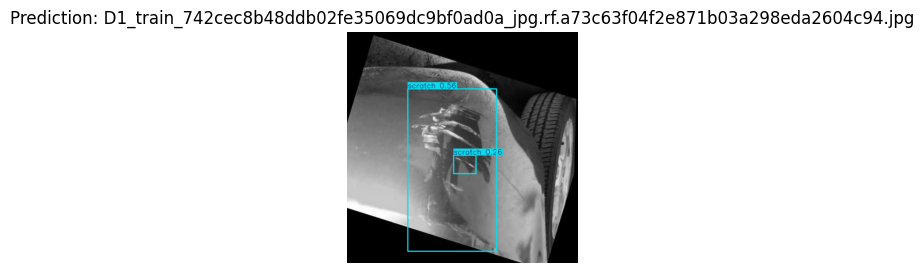


image 1/1 D:\IIT\4 th Year\Machine Vision\Course Work\Car-Damage-Detection-YOLO\data\car_damage_yolo\images\test\D1_train_accident-damage-22466802_jpg.rf.9ed32571362e8045eb37c042b1047ce9.jpg: 640x640 4 dents, 4 scratchs, 26.3ms
Speed: 1.6ms preprocess, 26.3ms inference, 1.6ms postprocess per image at shape (1, 3, 640, 640)


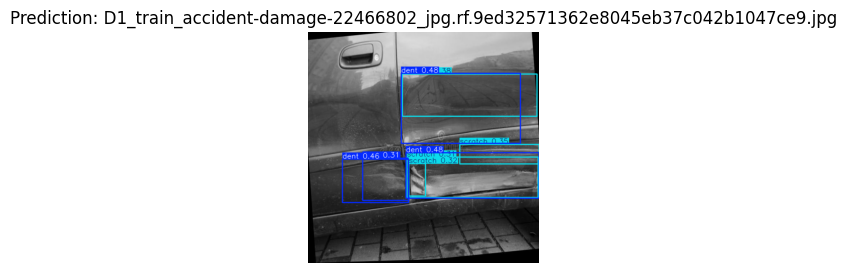


image 1/1 D:\IIT\4 th Year\Machine Vision\Course Work\Car-Damage-Detection-YOLO\data\car_damage_yolo\images\test\D1_train_auto-body-repair-series-mechanic-checking-dent-white-car-bonnet-58249344_jpg.rf.ffd202561cbb4d786c10f363bc574664.jpg: 640x640 3 scratchs, 27.0ms
Speed: 2.0ms preprocess, 27.0ms inference, 2.0ms postprocess per image at shape (1, 3, 640, 640)


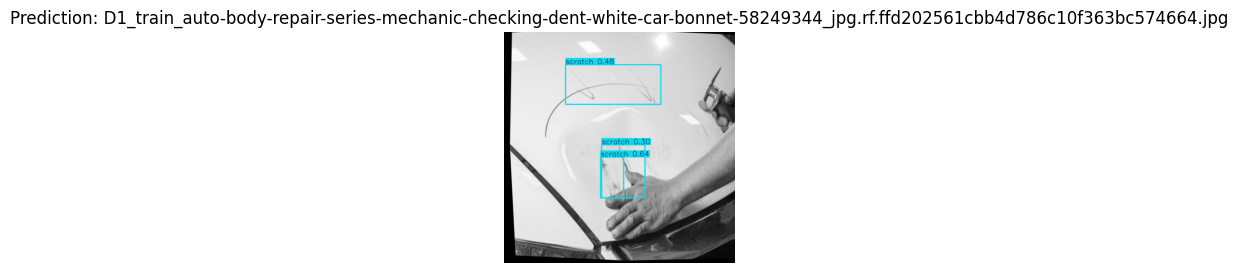

In [12]:
best_weights_path = r"D:\IIT\4 th Year\Machine Vision\Course Work\Car-Damage-Detection-YOLO\models\runs\car_damage_yolov8s\weights\best.pt"
model_best = YOLO(best_weights_path)

test_dir = os.path.join(DATA_DIR, "images", "test")
test_imgs = os.listdir(test_dir)[:6]

for img_name in test_imgs:
    img_path = os.path.join(test_dir, img_name)
    results = model_best(img_path)

    for r in results:
        plotted = r.plot()
        plt.figure(figsize=(3, 3))
        plt.imshow(cv2.cvtColor(plotted, cv2.COLOR_BGR2RGB))
        plt.title(f"Prediction: {img_name}")
        plt.axis("off")
        plt.show()


image 1/1 C:\Users\ASUS\Downloads\damage_car.jpg: 448x640 1 dent, 3 scratchs, 249.0ms
Speed: 11.3ms preprocess, 249.0ms inference, 1.8ms postprocess per image at shape (1, 3, 448, 640)


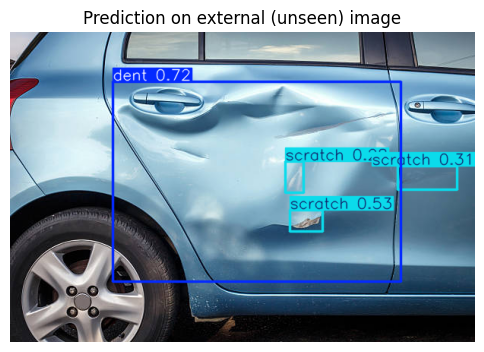

In [25]:
# Test on an external image not from the dataset
external_img_path = r"C:\Users\ASUS\Downloads\damage_car.jpg"

results = model_best(external_img_path)

for r in results:
    plotted = r.plot()
    plt.figure(figsize=(6, 6))
    plt.imshow(cv2.cvtColor(plotted, cv2.COLOR_BGR2RGB))
    plt.title("Prediction on external (unseen) image")
    plt.axis("off")
    plt.show()

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import os

csv_path = r"D:\IIT\4 th Year\Machine Vision\Course Work\Car-Damage-Detection-YOLO\models\runs\car_damage_yolov8s\results.csv"

df = pd.read_csv(csv_path)

# Strip spaces from column names
df.columns = [c.strip() for c in df.columns]

print(df.columns)

Index(['epoch', 'time', 'train/box_loss', 'train/cls_loss', 'train/dfl_loss',
       'metrics/precision(B)', 'metrics/recall(B)', 'metrics/mAP50(B)',
       'metrics/mAP50-95(B)', 'val/box_loss', 'val/cls_loss', 'val/dfl_loss',
       'lr/pg0', 'lr/pg1', 'lr/pg2'],
      dtype='object')


Using columns: metrics/mAP50(B) and train/box_loss


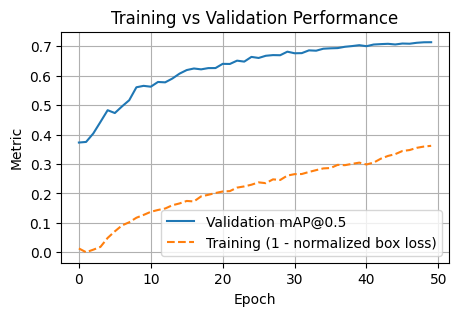

In [17]:
# Try to find the mAP and train loss columns automatically
mAP_col = [c for c in df.columns if "metrics/mAP50" in c][0]
train_loss_col = [c for c in df.columns if "train/box_loss" in c][0]

print("Using columns:", mAP_col, "and", train_loss_col)

plt.figure(figsize=(5, 3))

# Validation "accuracy" = mAP@0.5
plt.plot(df[mAP_col], label="Validation mAP@0.5")

# Training "accuracy" proxy = 1 - normalized box loss (so higher is better)
train_loss_norm = df[train_loss_col] / df[train_loss_col].max()
plt.plot(1 - train_loss_norm, label="Training (1 - normalized box loss)", linestyle="--")

plt.title("Training vs Validation Performance")
plt.xlabel("Epoch")
plt.ylabel("Metric")
plt.legend()
plt.grid(True)
plt.show()